# Baseline Performance

Evaluated test cases:
- `BASE-01`
- `CRASH-01`
- `LATENCY-01`

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../../src").resolve()))
from faultlab.analysis import (
    load_csv,
    get_base_01_summary,
    get_crash_01_summary_df,
    get_latency_01_summary_df,
    QUARANTINE_COLORS,
)

EVALUATION_DIR = Path("../../tests/results/EVALUATION")
BASE_01_DIR = EVALUATION_DIR.joinpath("1_BASELINE/BASE_01")
LATENCY_01_DIR = EVALUATION_DIR.joinpath("1_BASELINE/LATENCY_01")
CRASH_01_DIR = EVALUATION_DIR.joinpath("1_BASELINE/CRASH_01")
FIGURES_DIR = Path("./figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")


## 1. `BASE-01` Summary

In [2]:
capacities = get_base_01_summary(BASE_01_DIR)
TPS_E2E = capacities["e2e_tps"]
TPS_SIGNING = capacities["signing_tps"]
TPS_HOT = capacities["hot_signing_tps"]

print("=== Baseline Capacities (CIRCUIT_BREAKER) ===")
print(f"Full Signing Throughput:        {TPS_SIGNING} TPS")
print(f"Hot-Phase Signing Throughput:   {TPS_HOT} TPS (Tx 501 to 1000 steady-state)")
print(f"End-to-End Throughput:          {TPS_E2E} TPS")

=== Baseline Capacities (CIRCUIT_BREAKER) ===
Full Signing Throughput:        79.63 TPS
Hot-Phase Signing Throughput:   118.83 TPS (Tx 501 to 1000 steady-state)
End-to-End Throughput:          40.49 TPS


## 1.1 Table 1: `CRASH-01` Throughput Degradation 

In [ ]:
crash_df = get_crash_01_summary_df(CRASH_01_DIR, base_tps=TPS_SIGNING)
print("=== Table 1: CRASH-01 Throughput Degradation ===")
display(crash_df)

=== CRASH-01 Throughput Degradation ===


,Quarantine Mode,Signing Throughput (TPS),Throughput Degradation (%)
0,DISABLED,72.14,9.4
1,CIRCUIT_BREAKER,81.56,0.0


## 2. Figure 1: `BASE-01` vs `CRASH-01` Signing Throughput

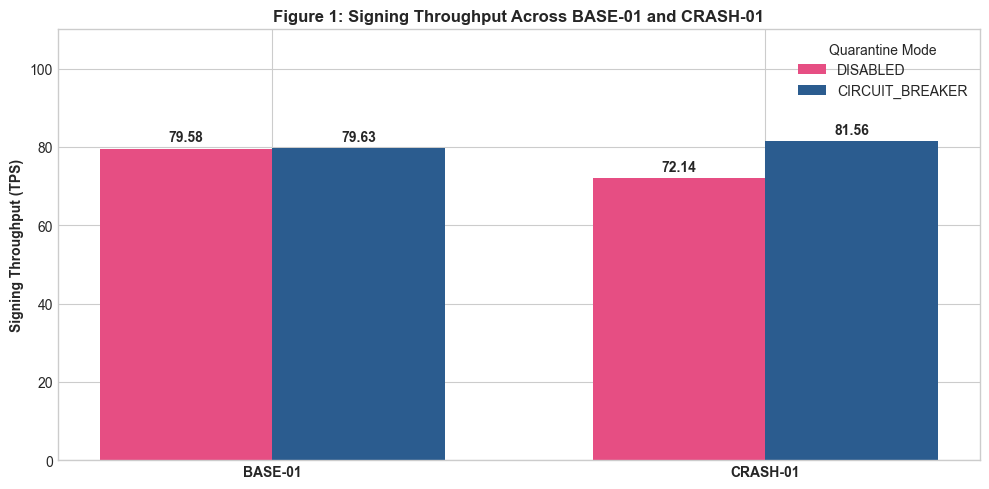

In [4]:
def fig_1():
    runs = {"DISABLED": [], "CIRCUIT_BREAKER": []}
    for mode_key, label in [("disabled", "DISABLED"), ("circuit_breaker", "CIRCUIT_BREAKER")]:
        for file_path in sorted(BASE_01_DIR.glob(f"*{mode_key}*.csv")):
            df = load_csv(file_path)
            sub = df[df["signed_at"].notna()].copy()
            dur = (sub["signed_at"].max() - df["created_at"].min()).total_seconds()
            if dur > 0:
                runs[label].append(len(sub) / dur)

    base_medians = {m: float(pd.Series(runs[m]).median()) if runs[m] else 0 for m in ["DISABLED", "CIRCUIT_BREAKER"]}
    crash_medians = {m: float(crash_df.loc[crash_df["Quarantine Mode"] == m, "Signing Throughput (TPS)"].iloc[0]) for m in ["DISABLED", "CIRCUIT_BREAKER"]}

    fig, ax = plt.subplots(figsize=(10, 5))
    tests = ["BASE-01", "CRASH-01"]
    x = np.arange(len(tests), dtype=float)
    width = 0.35

    disabled_vals = [base_medians["DISABLED"], crash_medians["DISABLED"]]
    cb_vals = [base_medians["CIRCUIT_BREAKER"], crash_medians["CIRCUIT_BREAKER"]]

    rects1 = ax.bar(x - width/2, disabled_vals, width, label="DISABLED", color=QUARANTINE_COLORS["DISABLED"])
    rects2 = ax.bar(x + width/2, cb_vals, width, label="CIRCUIT_BREAKER", color=QUARANTINE_COLORS["CIRCUIT_BREAKER"])

    ax.set_title("Figure 1: Signing Throughput Across BASE-01 and CRASH-01", fontweight="bold")
    ax.set_ylabel("Signing Throughput (TPS)", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(tests, fontweight="bold")
    ax.set_ylim(0, 110)
    ax.legend(loc="upper right", title="Quarantine Mode")

    ax.bar_label(rects1, fmt="%.2f", padding=3, fontweight="bold")
    ax.bar_label(rects2, fmt="%.2f", padding=3, fontweight="bold")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR.joinpath("FIG_1_Baseline_Throughput.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

fig_1()

## 3. Figure 2: Signing Throughput Trajectory for `BASE-01`

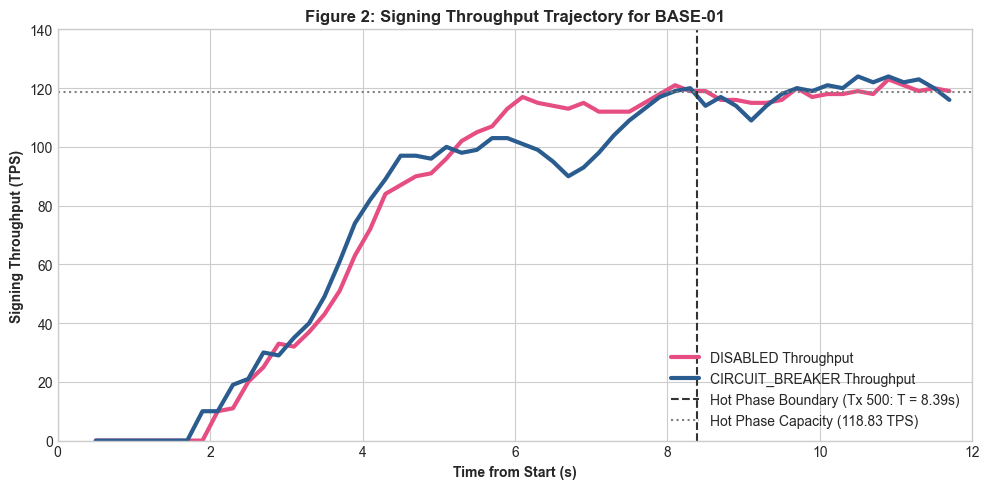

In [5]:
def fig_2():
    time_points = np.arange(0.5, 11.9, 0.2) # Starting from 0.5 to 11.9 with step of 0.2 
    fig, ax = plt.subplots(figsize=(10, 5))

    for mode_key, label in [("disabled", "DISABLED"), ("circuit_breaker", "CIRCUIT_BREAKER")]:
        runs = []
        for file_path in sorted(BASE_01_DIR.glob(f"*{mode_key}*.csv")):
            df = load_csv(file_path)
            sub = df[df["signed_at"].notna()].copy()
            sub["sec"] = (sub["signed_at"] - df["created_at"].min()).dt.total_seconds()
            runs.append(sub)
        if not runs:
            continue

        tps_curves = [
            [((r["sec"] >= tp - 0.5) & (r["sec"] < tp + 0.5)).sum() for tp in time_points]
            for r in runs
        ] # Evaluate for 1s sliding window having step of 0.2s results in 80% overlap giving smooth line
        med_curve = np.median(tps_curves, axis=0)
        ax.plot(time_points, med_curve, color=QUARANTINE_COLORS[label], linewidth=3, label=f"{label} Throughput")

    # Calculate median completion timestamp of Tx 500 across CIRCUIT_BREAKER runs
    cb_runs = [r for file_path in sorted(BASE_01_DIR.glob("*circuit_breaker*.csv")) if (r := load_csv(file_path)).empty is False]
    tx500_times = [(df[df["signed_at"].notna()]["signed_at"].min() - df["created_at"].min()).total_seconds() for df in cb_runs] # fallback
    tx500_times = [(df[df["signed_at"].notna()].copy().assign(sec=lambda d: (d["signed_at"] - df["created_at"].min()).dt.total_seconds()).sort_values("sec").iloc[499]["sec"]) for df in cb_runs if len(df[df["signed_at"].notna()]) >= 500]
    t500_med = round(float(np.median(tx500_times)), 2) if tx500_times else 8.27

    ax.axvline(x=t500_med, color="#333333", linestyle="--", linewidth=1.5, label=f"Hot Phase Boundary (Tx 500: T = {t500_med}s)")
    ax.axhline(y=TPS_HOT, color="gray", linestyle=":", linewidth=1.5, label=f"Hot Phase Capacity ({TPS_HOT} TPS)")

    ax.set_title("Figure 2: Signing Throughput Trajectory for BASE-01", fontweight="bold")
    ax.set_xlabel("Time from Start (s)", fontweight="bold")
    ax.set_ylabel("Signing Throughput (TPS)", fontweight="bold")
    ax.set_xlim(0, 12.0)
    ax.set_ylim(0, 140)
    ax.legend(loc="lower right")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR.joinpath("FIG_2_Throughput_Trajectory.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

fig_2()

## 4. Figure 3: Latency Breakdown Under `LATENCY-01`

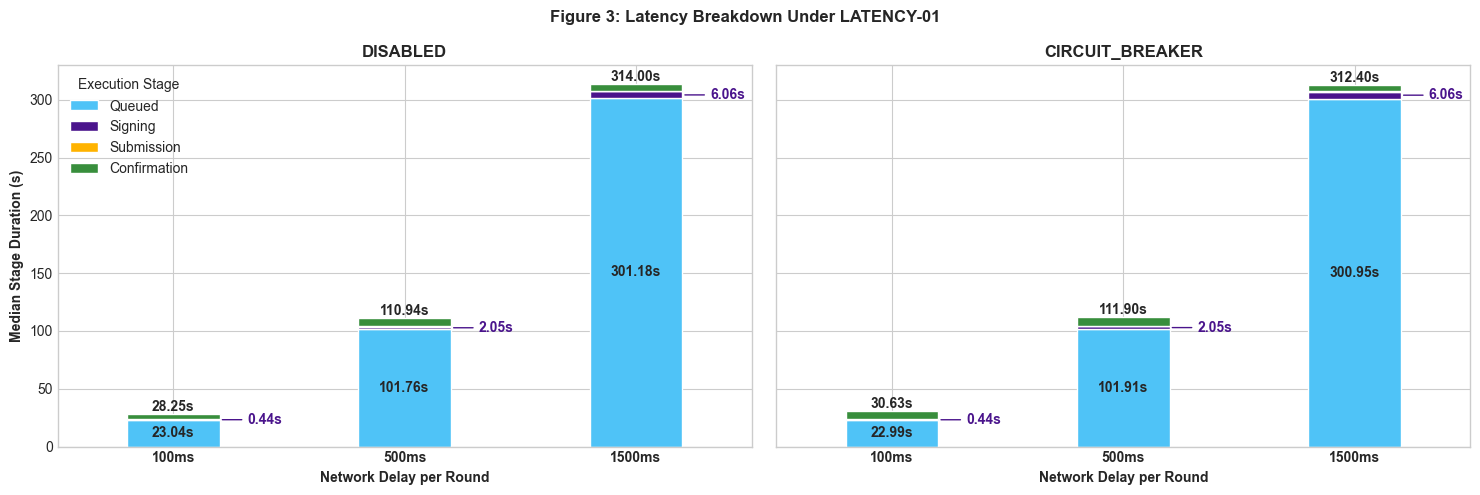

In [6]:
latency_df = get_latency_01_summary_df(LATENCY_01_DIR)

def fig_3():
    stages = [
        ("Queued (s)", "#4fc3f7"),
        ("Signing (s)", "#4a148c"),
        ("Submission (s)", "#ffb300"),
        ("Confirmation (s)", "#388e3c"),
    ]
    modes = ["DISABLED", "CIRCUIT_BREAKER"]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

    for idx, mode in enumerate(modes):
        ax = axes[idx]
        sub = latency_df[latency_df["Mode"] == mode].copy()
        if sub.empty: continue

        delays = sub["Delay (ms)"].astype(str) + "ms"
        x = np.arange(len(delays), dtype=float)
        bottom_stack = np.zeros(len(delays), dtype=float)
        bar_width = 0.4

        for label, color in stages:
            stage_values = sub[label].values
            legend_label = label.split()[0] if idx == 0 else "_nolegend_"
            ax.bar(x, stage_values, bar_width, label=legend_label, bottom=bottom_stack, color=color, edgecolor="white", linewidth=1)
            bottom_stack += stage_values

        queued_values = sub["Queued (s)"].values
        signing_values = sub["Signing (s)"].values

        for bar_index in range(len(x)):
            queued_seconds = queued_values[bar_index]
            signing_seconds = signing_values[bar_index]
            total_latency_seconds = bottom_stack[bar_index]

            # 1. Total top label
            ax.annotate(f"{total_latency_seconds:.2f}s", xy=(x[bar_index], total_latency_seconds),  ha="center", va="bottom", fontweight="bold")

            # 2. Queued inside label
            ax.annotate(f"{queued_seconds:.2f}s", xy=(x[bar_index], queued_seconds / 2.0), ha="center", va="center", fontweight="bold")

            # 3. Signing callout label with leader line
            ax.annotate(
                f"{signing_seconds:.2f}s",
                xy=(x[bar_index] + bar_width / 2.0, queued_seconds + signing_seconds / 2.0),
                xytext=(20, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontweight="bold",
                color="#4a148c",
                arrowprops=dict(arrowstyle="-", color="#4a148c"),
            )

        ax.set_title(f"{mode}", fontweight="bold")
        ax.set_xlabel("Network Delay per Round", fontweight="bold")
        if idx == 0:
            ax.set_ylabel("Median Stage Duration (s)", fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(delays, fontweight="bold")
        ax.set_xlim(-0.5, len(x) - 0.5)

    axes[0].legend(loc="upper left", title="Execution Stage")
    plt.suptitle("Figure 3: Latency Breakdown Under LATENCY-01", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR.joinpath("FIG_3_Latency_Breakdown.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

fig_3()